<img src="https://uwe-cyber.github.io/images/uwe_banner.png">

# UFCFEL Security Data Analytics and Visualisation
## Portfolio Assignment: Part 2
### Academic year: 2025-26
## Conduct a security investigation to examine and classify different malware characteristics
---

For this task, the company **UWEtech** have enlisted your support as a security data analyst once again. They believe they have found malware on some of their workstations; however they do not know what malware it is. They also believe that some machines may be infected with different kinds of malware. They have asked you to identify what malware is running on each of the contaminated machines, so that they may understand more about how this incident has occurred on their corporate network.

**Dataset:** You will be issued a dataset for this task via GitLab: https://gitlab.uwe.ac.uk/a23-mccarthy/sdav-2025

**This exercise carries a weight of 30% towards your overall portfolio submission**

### Submission Documents
---

For Part 2 of your portfolio, your complete output file should be saved as:

- **STUDENT_ID-PART2.ipynb**

This should then be included in a ZIP file along with your other two portfolio documents.

The deadline for your portfolio submission is **THURSDAY 11th DECEMBER @ 14:00**. 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

features = pd.read_csv('malware_data.csv', header=None)
features

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,224862.0,15842.0,12985.0,7387.0,13132.0,5112.0,8661.0,7990.0,14978.0,5656.0,...,3714.0,2892.0,9344.0,2415.0,2742.0,3023.0,11949.0,3662.0,5552.0,77433.0
1,21802.0,2127.0,2076.0,2028.0,1871.0,1622.0,1939.0,1502.0,2133.0,1689.0,...,1664.0,1607.0,1788.0,1394.0,1327.0,1453.0,1785.0,1559.0,1755.0,4882.0
2,24407.0,11682.0,7189.0,6538.0,7687.0,6848.0,4974.0,5377.0,7049.0,11642.0,...,5795.0,6053.0,6426.0,5435.0,4961.0,5026.0,5376.0,4180.0,5685.0,5775.0
3,7132.0,461.0,647.0,371.0,581.0,269.0,646.0,262.0,243.0,165.0,...,151.0,276.0,299.0,294.0,294.0,354.0,506.0,569.0,940.0,1516.0
4,5321.0,1108.0,985.0,955.0,958.0,890.0,971.0,919.0,945.0,963.0,...,933.0,975.0,945.0,924.0,879.0,952.0,956.0,900.0,942.0,1559.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,23849.0,1489.0,1573.0,2649.0,1560.0,1025.0,922.0,1020.0,1042.0,938.0,...,993.0,968.0,1165.0,1041.0,1258.0,1753.0,1203.0,958.0,1315.0,4342.0
27996,9267.0,1056.0,981.0,930.0,1573.0,819.0,879.0,1064.0,1029.0,893.0,...,998.0,911.0,990.0,1039.0,930.0,833.0,904.0,891.0,976.0,2683.0
27997,25357.0,874.0,1008.0,2781.0,1518.0,939.0,4267.0,968.0,1103.0,1032.0,...,563.0,557.0,974.0,706.0,514.0,632.0,657.0,584.0,535.0,2431.0
27998,29010.0,6476.0,2969.0,5358.0,2827.0,4598.0,2172.0,4045.0,2496.0,3718.0,...,217.0,146.0,544.0,232.0,95.0,140.0,294.0,163.0,182.0,4005.0


In [2]:
labels = pd.read_csv('malware_label.csv', header=None)
labels = labels.drop(0, axis=1)
labels = labels.rename(columns = {1:'label'})
labels.value_counts()

label     
bladabindi    2000
dealply       2000
emotet        2000
filetour      2000
flystudio     2000
gamarue       2000
gandcrab      2000
high          2000
razy          2000
startsurf     2000
upatre        2000
vittalia      2000
wannacry      2000
zbot          2000
Name: count, dtype: int64

In this dataset, we have collected data from 28000 systems (rows), where each system reports 256 parameters (columns).

We will first look at developing a small classifier "by hand", to help you understand how the classifier works, and then we will look at using the full dataset on more powerful classifiers to see whether we can classify the different malware varients on the set of workstations.

## Part 1: Developing a small classifier "by hand"

### Do not modify this cell

In [3]:
# DO NOT MODIFY THIS CELL
mal1_index = 17000
mal2_index = 21000
mal3_index = 12000
mal_range = 50
mal_test_range = 30

train_data = np.vstack([ features[mal1_index:mal1_index+mal_range][[0,1]].values, features[mal2_index:mal2_index+mal_range][[0,1]].values, features[mal3_index:mal3_index+mal_range][[0,1]].values ])
train_data = pd.DataFrame(train_data)
train_labels = np.vstack([ labels[mal1_index:mal1_index+mal_range].values, labels[mal2_index:mal2_index+mal_range].values, labels[mal3_index:mal3_index+mal_range].values ])
train_labels = pd.DataFrame(train_labels)
train_data['labels'] = train_labels
train_data = train_data.rename(columns={0:'x', 1:'y'})

test_data = np.vstack([ features[mal1_index+mal_range:mal1_index+mal_range+mal_test_range][[0,1]].values, features[mal2_index+mal_range:mal2_index+mal_range+mal_test_range][[0,1]].values, features[mal3_index+mal_range:mal3_index+mal_range+mal_test_range][[0,1]].values ])
test_data = pd.DataFrame(test_data)
test_labels = np.vstack([ labels[mal1_index+mal_range:mal1_index+mal_range+mal_test_range].values, labels[mal2_index+mal_range:mal2_index+mal_range+mal_test_range].values, labels[mal3_index+mal_range:mal3_index+mal_range+mal_test_range].values ])
test_labels = pd.DataFrame(test_labels)
test_data['labels'] = test_labels
test_data = test_data.rename(columns={0:'x', 1:'y'})

train_data

,x,y,labels
0,3114896.0,10815.0,wannacry
1,3436940.0,9551.0,wannacry
2,1812649.0,15343.0,wannacry
3,3067845.0,10541.0,wannacry
4,51591.0,21367.0,wannacry
...,...,...,...
145,78591.0,7734.0,razy
146,80429.0,5114.0,razy
147,2898.0,98.0,razy
148,183376.0,8477.0,razy


We now have a smaller sample of data to work with called train_data, that has three malware families included, and we have reduced the number of features to make it easier to understand the process of how the classifier operates.

### Question 1: Find the Centroid point of each of the three groups
#### (2 marks)

*Hint: We have filtered the sample to a new variable called **train_data**. Also, think about how to find the mid-point of a set of co-ordinate points **x** and **y**.*

In [13]:


wannacry_centroid = [
    train_data[train_data['labels'] == 'wannacry']['x'].mean(),
    train_data[train_data['labels'] == 'wannacry']['y'].mean()
]

razy_centroid = [
    train_data[train_data['labels'] == 'razy']['x'].mean(),
    train_data[train_data['labels'] == 'razy']['y'].mean()
]

startsurf_centroid = [
    train_data[train_data['labels'] == 'startsurf']['x'].mean(),
    train_data[train_data['labels'] == 'startsurf']['y'].mean()
]

print("Wannacry: ", wannacry_centroid)
print("Razy: ", razy_centroid)
print("Startsurf: ", startsurf_centroid)


Wannacry:  [2181660.66, 11087.1]
Razy:  [100505.22, 6158.28]
Startsurf:  [478778.12, 3754.04]


### Question 2: Create a Scatter Plot that shows both the train data and the corresponding centroids. Colour-code your data by group, and use a different visual marker for the centroid.

#### (2 marks)

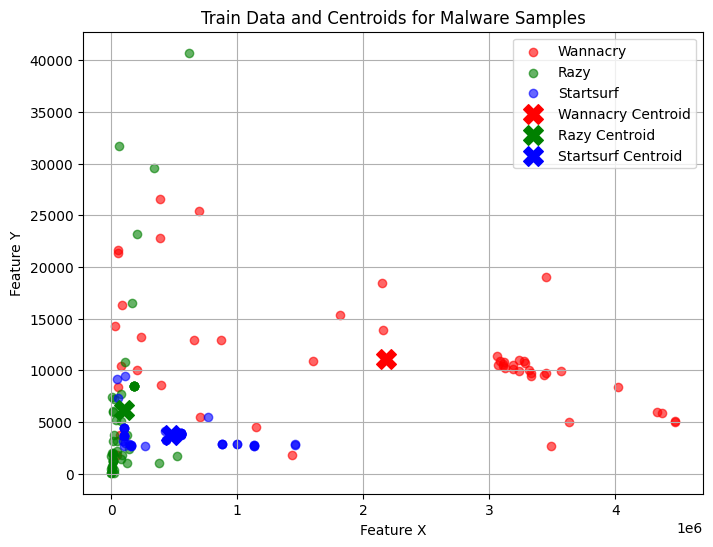

In [5]:
# ANSWER

plt.figure(figsize=(8,6))

# Plot each malware type with its own color
plt.scatter(train_data[train_data['labels'] == 'wannacry']['x'],
            train_data[train_data['labels'] == 'wannacry']['y'],
            color='red', label='Wannacry', alpha=0.6)

plt.scatter(train_data[train_data['labels'] == 'razy']['x'],
            train_data[train_data['labels'] == 'razy']['y'],
            color='green', label='Razy', alpha=0.6)

plt.scatter(train_data[train_data['labels'] == 'startsurf']['x'],
            train_data[train_data['labels'] == 'startsurf']['y'],
            color='blue', label='Startsurf', alpha=0.6)

# Plot the centroids with distinct markers
plt.scatter(wannacry_centroid[0], wannacry_centroid[1],
            color='red', marker='X', s=200, label='Wannacry Centroid')
plt.scatter(razy_centroid[0], razy_centroid[1],
            color='green', marker='X', s=200, label='Razy Centroid')
plt.scatter(startsurf_centroid[0], startsurf_centroid[1],
            color='blue', marker='X', s=200, label='Startsurf Centroid')

# Add labels and legend
plt.title('Train Data and Centroids for Malware Samples')
plt.xlabel('Feature X')
plt.ylabel('Feature Y')
plt.legend()
plt.grid(True)
plt.show()


### Question 3a: For each point in test_data, calculate the Euclidean distance between the point and each of the three centroid points 

#### (3 marks)

### Question 3b: Use the closest centroid to assign membership and compare against the test data label to obtain a score of successful classifications 

#### (3 marks)

*Hint: You may find the clustering activity worksheet helpful for how to approach this task, and you will likely want to answer both questions within the same for loop below.*

In [14]:
# ANSWER — Q3a and Q3b

import numpy as np
import pandas as pd

# Pack centroids in a dict
centroids = {
    'wannacry': (float(wannacry_centroid[0]), float(wannacry_centroid[1])),
    'razy': (float(razy_centroid[0]), float(razy_centroid[1])),
    'startsurf': (float(startsurf_centroid[0]), float(startsurf_centroid[1]))
}

# Prepare columns to store distances and predictions
test_data = test_data.copy()
test_data['dist_wannacry'] = np.nan
test_data['dist_razy'] = np.nan
test_data['dist_startsurf'] = np.nan
test_data['predicted'] = None

# Helper: Euclidean distance in 2D
def euclid(p, q):
    return np.sqrt((p[0] - q[0])**2 + (p[1] - q[1])**2)


for idx, row in test_data.iterrows():
    px, py = row['x'], row['y']

    d_w = euclid((px, py), centroids['wannacry'])
    d_r = euclid((px, py), centroids['razy'])
    d_s = euclid((px, py), centroids['startsurf'])

    test_data.at[idx, 'dist_wannacry'] = d_w
    test_data.at[idx, 'dist_razy'] = d_r
    test_data.at[idx, 'dist_startsurf'] = d_s

    # choose the closest centroid
    nearest = min(
        [('wannacry', d_w), ('razy', d_r), ('startsurf', d_s)],
        key=lambda t: t[1]
    )[0]
    test_data.at[idx, 'predicted'] = nearest

# Evaluate Q3b: accuracy and confusion matrix
accuracy = (test_data['predicted'] == test_data['labels']).mean()

print(f"Accuracy on test_data: {accuracy:.3f}  "
      f"({(accuracy*100):.1f}%)")

print("\nConfusion matrix (rows=true, cols=predicted):")
print(pd.crosstab(test_data['labels'], test_data['predicted']))


Accuracy on test_data: 0.700  (70.0%)

Confusion matrix (rows=true, cols=predicted):
predicted  razy  startsurf  wannacry
labels                              
razy         30          0         0
startsurf    12         15         3
wannacry      8          4        18


### Task 4: Provide a final accuracy score for the performance of your "by hand" classifier 

#### (1 marks)

In [16]:


final_accuracy = (test_data['predicted'] == test_data['labels']).mean()
print(f"Final accuracy score of the by-hand classifier: {final_accuracy:.2%}")


Final accuracy score of the by-hand classifier: 70.00%


## Part 2: Developing a large-scale ML classifier

We will now extend the earlier principles for the full dataset. Essentially the task is the same, we want to find the parameters that allow us to clearly separate groups for classification. You will want to consult the [scikit-learn documentation](https://scikit-learn.org/stable/index.html) to answer the following questions.

### Question 5: Scale the Features DataFrame using the StandardScaler function 

#### (1 mark)

*Hint: The variable **features** contains all of the numerical parameters that we will use to train our ML model, which we need to normalise using this function.*

In [ ]:


from sklearn.preprocessing import StandardScaler

# Create a scaler instance
scaler = StandardScaler()

# Fit the scaler to the feature data and transform it
scaled_features = scaler.fit_transform(features)

# Convert back to DataFrame for readability and consistency
scaled_features = pd.DataFrame(scaled_features)

# Display confirmation
print("Feature data successfully scaled using StandardScaler.")
scaled_features.head()


Feature data successfully scaled using StandardScaler.


,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,-0.097820,0.672159,0.826630,0.380661,0.647650,0.204495,0.792002,0.691117,1.028243,0.432558,...,0.191715,0.044177,0.845365,-0.010620,0.038420,0.068183,1.190714,0.135741,0.178144,0.406173
1,-0.355085,-0.291567,-0.274569,-0.254820,-0.323318,-0.234858,-0.178266,-0.244002,-0.310024,-0.182924,...,-0.155188,-0.155994,-0.248598,-0.175093,-0.166129,-0.179846,-0.248456,-0.168900,-0.218099,-0.238666
2,-0.351784,0.379844,0.241558,0.279985,0.178160,0.423038,0.259812,0.314504,0.202153,1.361289,...,0.543863,0.536584,0.422895,0.475873,0.359192,0.384618,0.260011,0.210779,0.192024,-0.230729
3,-0.373671,-0.408634,-0.418818,-0.451310,-0.434547,-0.405185,-0.364900,-0.422724,-0.506936,-0.419373,...,-0.411219,-0.363332,-0.464176,-0.352293,-0.315456,-0.353466,-0.429556,-0.312311,-0.303149,-0.268583
4,-0.375965,-0.363170,-0.384699,-0.382059,-0.402040,-0.327008,-0.317989,-0.328030,-0.433797,-0.295563,...,-0.278888,-0.254445,-0.370648,-0.250806,-0.230890,-0.258994,-0.365838,-0.264363,-0.302941,-0.268201


### Question 6: Use the LabelEncoder function on the Labels variable to obtain numerical label data 

#### (1 mark)

In [ ]:


from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
le = LabelEncoder()

# Fit the encoder to the label data and transform it
encoded_labels = le.fit_transform(labels['label'])

# Convert to DataFrame for readability
encoded_labels = pd.DataFrame(encoded_labels, columns=['encoded_label'])

# Display confirmation and mapping
print("Label data successfully encoded using LabelEncoder.\n")
print("Class mapping (label → encoded value):")
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f"{label} → {code}")

# Show first few encoded labels
encoded_labels.head()


Label data successfully encoded using LabelEncoder.

Class mapping (label → encoded value):
bladabindi → 0
dealply → 1
emotet → 2
filetour → 3
flystudio → 4
gamarue → 5
gandcrab → 6
high → 7
razy → 8
startsurf → 9
upatre → 10
vittalia → 11
wannacry → 12
zbot → 13


,encoded_label
0,7
1,7
2,7
3,7
4,7


### Question 7: Prepare the dataset for ML testing using the Train-Test-Split function
#### (1 mark)

In [18]:
# ANSWER — Question 7

from sklearn.model_selection import train_test_split
import numpy as np

# Features (X) and labels (y)
X = scaled_features.values                     
y = encoded_labels['encoded_label'].values    

# Train/test split (stratified to keep class balance), reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Quick confirmation
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Shapes:
X_train: (22400, 256) y_train: (22400,)
X_test : (5600, 256) y_test : (5600,)


### Question 8: Use a Multi-Layer Perceptron (MLP) classifier to train a machine learning model, and obtain the accuracy score against your test data. 

#### (3 marks)

In [20]:

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42,
    verbose=False   
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"MLP Test Accuracy: {acc:.2%}")
print("Iterations used:", mlp.n_iter_)
print("Final training loss:", mlp.loss_)



MLP Test Accuracy: 79.48%
Iterations used: 54
Final training loss: 0.48610882416413365


### Question 9: Use a Random Forest (RF) classifier to train a machine learning model, and obtain the accuracy score against your test data. 

#### (3 marks)

In [21]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

try:
    X_train, X_test, y_train, y_test  # just to check existence
except NameError:
    # Build X and y from earlier prepared variables
    X = scaled_features.values
    y = encoded_labels['encoded_label'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42
    )

# Train a Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,          # let trees grow fully (stop via other criteria)
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    n_jobs=-1,               
    random_state=42
)

rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Test Accuracy: {rf_accuracy:.2%}")


cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix shape:", cm.shape)


importances = rf.feature_importances_
topk = 10
top_idx = np.argsort(importances)[::-1][:topk]
top_table = pd.DataFrame({
    'feature_index': top_idx,
    'importance': importances[top_idx]
})
print("\nTop 10 feature importances:")
print(top_table.to_string(index=False))


Random Forest Test Accuracy: 88.16%
Confusion matrix shape: (14, 14)

Top 10 feature importances:
 feature_index  importance
            36    0.016217
             0    0.014068
           139    0.012410
           138    0.011204
            64    0.010876
           137    0.010680
           131    0.010419
           231    0.009557
           144    0.009463
            68    0.008596


### Question 10: Describe what you believe are the key findings of this task, comparing the *by-hand* classifier with the MLP classifier. As part of your discussion, consider the volume of data in both approaches and the issues of data separability. Give justifications for your answer. Limit your response to a maximum of 300 words.

#### (10 marks).